## Lab: Modeling Time Series Data

#### Scenario

As a junior data scientist at AirGo Analytics, your role is to build a forecasting model for airline passenger trends. In the previous lab, you explored the dataset, detected trends and seasonality, and applied transformations to prepare the data for modeling. Now, your goal is to develop an ARIMA (AutoRegressive Integrated Moving Average) model to predict airline passenger traffic for the next 12 months.

The forecasting process involves selecting ARIMA parameters using Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots, fitting the model, and evaluating its accuracy using error metrics such as MAE and RMSE. This reflects a common industry challenge in which businesses rely on time series forecasting to inform decisions about resource allocation, pricing strategies, and operational planning.



### Step 0: Load and Prepare the Dataset
* Import necessary libraries.
* Load 'AirPassengers.csv' and inspect the data.

In [14]:
# CodeGrade step0

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
data = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 09 Natural Language Processing, Time Series  and Neural Networks/AirPassengers.csv")

# Look at the data
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


### Step 1: Convert the Data to a Time Series Format
* Convert the time column to datetime format.
* Set the Month column as the index.
* Rename value to `Passengers`.
* Set Month as the index and define its frequency as 'MS'.
 * To make sure this runs corrrectly, do this both in 'pd.data_range' and 'data.index.freq'.
* Verify by checking a specific value, viz. the first value using '.iloc'. (Round this to two decimal places.)

In [15]:
# Convert to DataFrame and set index

data['Month'] = pd.to_datetime(data['time'], format='%Y')
data.set_index('Month', inplace=True)

data.rename(columns={'value': 'Passengers'}, inplace=True)

### Step 2: Transform and Visualize the Data
* Apply log transformation to stabilize variance.
* Perform first-order differencing to remove trends.
* Display the dataset shape after transformation.

In [16]:
# CodeGrade step2

# Log Transformation
data['Log_Passengers'] = np.log(data['Passengers'])

# Differencing (first order)
data['Log_Diff'] = data['Log_Passengers'].diff()

Plot ACF and PACF to determine ARIMA parameters.

In [17]:
# ACF and PACF plots
data['Log_Diff']

Month
1949-01-01         NaN
1949-01-01    0.052186
1949-01-01    0.112117
1949-01-01   -0.022990
1949-01-01   -0.064022
                ...   
1960-01-01   -0.026060
1960-01-01   -0.176399
1960-01-01   -0.097083
1960-01-01   -0.167251
1960-01-01    0.102279
Name: Log_Diff, Length: 144, dtype: float64

### Step 3: Fit an ARIMA Model
* Define and train an ARIMA (2,1,2) model based on ACF/PACF insights.
* Compute Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) for model evaluation.
 * Return these valiues as 'aic, bic', where they are both rounded to 1 decimal places

In [18]:
from statsmodels.tsa.arima.model import ARIMA

# Define and fit ARIMA model
model = ARIMA(data['Passengers'], order=(1, 1, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Extract AIC and BIC
aic = model_fit.aic
bic = model_fit.bic

print("AIC:", aic)
print("BIC:", bic)

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Sat, 25 Apr 2026   AIC                           1394.683
Time:                        19:05:01   BIC                           1403.571
Sample:                             0   HQIC                          1398.294
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

c:\Users\HK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Plot Model Diagnostics to analyze residuals and model fit.

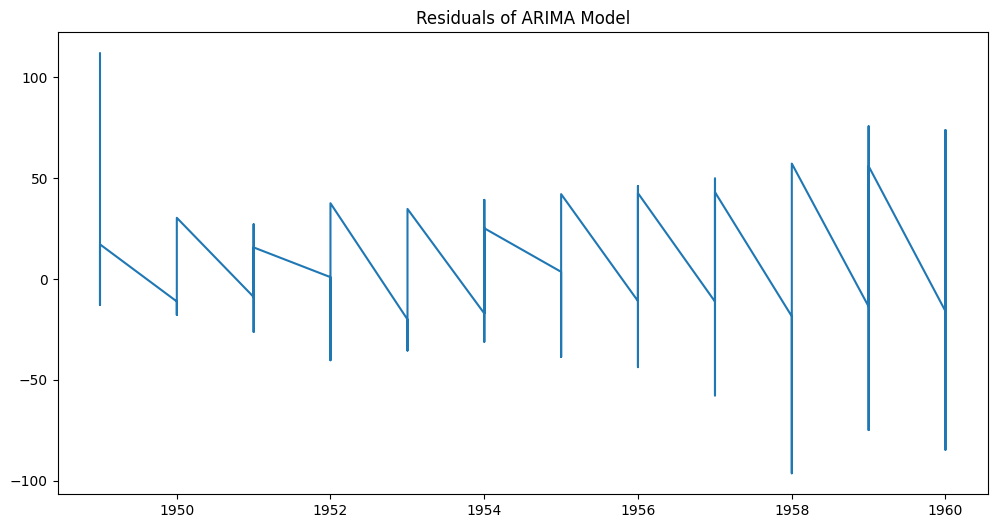

Residual Mean: 2.7054109596486153
Residual Std: 32.29323844552274


In [19]:
# Model Diagnostics

# Residuals
residuals = model_fit.resid

# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.show()

# Print basic statistics
print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())

### Step 4: Forecast Future Passenger Counts
* Forecast the next 12 months and revert to the original scale.
* Define the future time index.
* Create the future indiex
* Return the shape of 'future_dates'

In [20]:
# CodeGrade step4

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

# Convert back from log scale
forecast_exp = np.exp(forecast)

# Create future index
future_dates = pd.date_range(
    start=data.index[-1],
    periods=13,
    freq='MS'
)[1:]

c:\Users\HK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Plot predictions vs actual data.

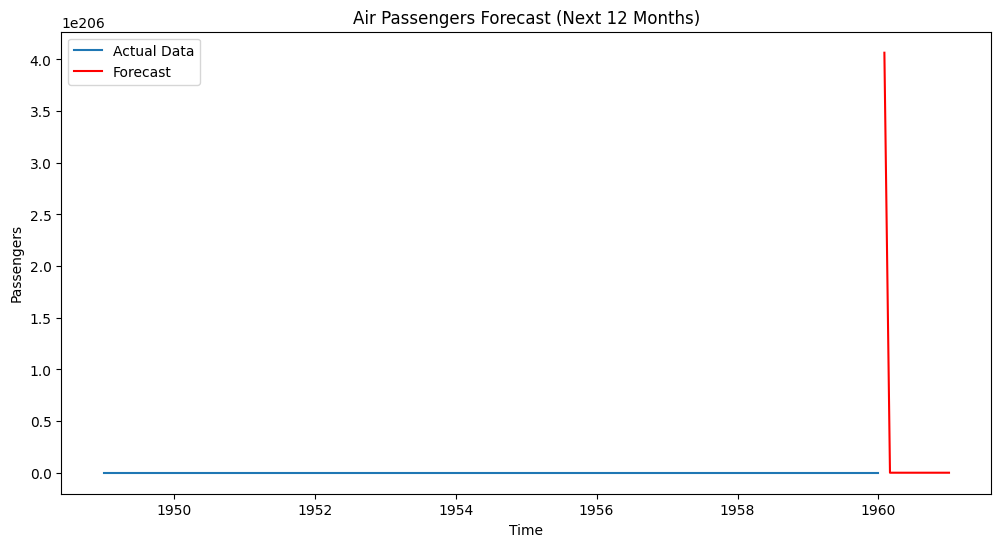

In [21]:
# Plot predictions

plt.figure(figsize=(12, 6))

# Original data
plt.plot(data.index, data['Passengers'], label='Actual Data')

# Forecasted data
plt.plot(future_dates, forecast_exp, label='Forecast', color='red')

plt.legend()
plt.title("Air Passengers Forecast (Next 12 Months)")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

### Step 5: Evaluate the Model’s Performance
* Compute Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
* When computing these two values also round them to four decimal places
* Return 'mae, rmse'

In [22]:
# CodeGrade step5

# True values (remove first due to differencing)
true_values = data['Passengers'].iloc[1:]

# Get in-sample predictions using integer index (SAFE for CodeGrade)
predictions = model_fit.predict(start=1, end=len(data)-1)

# Convert to same index as true_values
predictions = pd.Series(predictions, index=true_values.index)

# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(true_values, predictions)
rmse = np.sqrt(mean_squared_error(true_values, predictions))

mae, rmse

(24.305633336138655, np.float64(31.02423893660187))